# Validation

This notebook validates the core geometry of `postmodes` on synthetic covariance matrices with known properties.

The point is simple: we build posteriors with controlled features,

- known PCA directions,
- known PCA rotations,
- known generalized variance ratios `\rho_i`,
- known whitening/comparison matrix,

and then feed them into the package to check that the reported outputs recover the design inputs.

This notebook is intentionally theoretical and synthetic. It is meant as a validation layer, not as a realistic data-analysis example.

Version 1.0.0: Cases 1, 3 and 4 explicitly retain the original-coordinate rotation metric used to design their angles. Case 5 tests the new reference-standardized default. All previous figures are retained.


In [1]:
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from postmodes import analyze_covariances
from postmodes.interpretation import (
    eigenmode_report,
    top_eigenvector_alignments,
)


## Utilities

We work mostly in 2D because the geometry is easy to visualize.

A covariance matrix can be written as

$
C = R(\theta)
\begin{pmatrix}
\sigma_1^2 & 0 \\
0 & \sigma_2^2
\end{pmatrix}
R(\theta)^T,
$

where $R(\theta)$ is a rotation matrix. This gives us direct control over:

- the axis lengths, through $\sigma_1^2$ and $\sigma_2^2$,
- the axis orientation, through $\theta$.


In [2]:
def rotation_matrix(theta_deg: float) -> np.ndarray:
    theta = np.deg2rad(theta_deg)
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])


def covariance_from_axes(sigmas, theta_deg: float) -> np.ndarray:
    R = rotation_matrix(theta_deg)
    D = np.diag(np.square(sigmas))
    return R @ D @ R.T


def draw_covariance_ellipse(ax, cov, color, label, center=(0.0, 0.0), nsigma=1.0, lw=2.5, alpha=1.0):
    evals, evecs = np.linalg.eigh(cov)
    order = np.argsort(evals)[::-1]
    evals = evals[order]
    evecs = evecs[:, order]

    width = 2.0 * nsigma * np.sqrt(evals[0])
    height = 2.0 * nsigma * np.sqrt(evals[1])
    angle = np.degrees(np.arctan2(evecs[1, 0], evecs[0, 0]))

    ellipse = Ellipse(
        xy=center,
        width=width,
        height=height,
        angle=angle,
        facecolor='none',
        edgecolor=color,
        linewidth=lw,
        alpha=alpha,
        label=label,
    )
    ax.add_patch(ellipse)

    for i in range(2):
        vec = evecs[:, i] * np.sqrt(evals[i]) * nsigma
        ax.arrow(center[0], center[1], vec[0], vec[1],
                 color=color, width=0.0, head_width=0.04, length_includes_head=True, alpha=alpha)


def pretty_matrix(M, precision=4):
    return np.array2string(M, precision=precision, suppress_small=False)


## Case 1: Pure PCA Rotation Test

Here we test only the PCA rotation logic.

We build two posteriors with:

- the same eigenvalues,
- different PCA orientations.

So the expected behavior is:

- the PCA eigenvalues of `A` and `B` should match,
- the overlap matrix should clearly show a finite rotation,
- the generalized comparison should reflect a pure relative geometric change rather than a trivial isotropic rescaling.


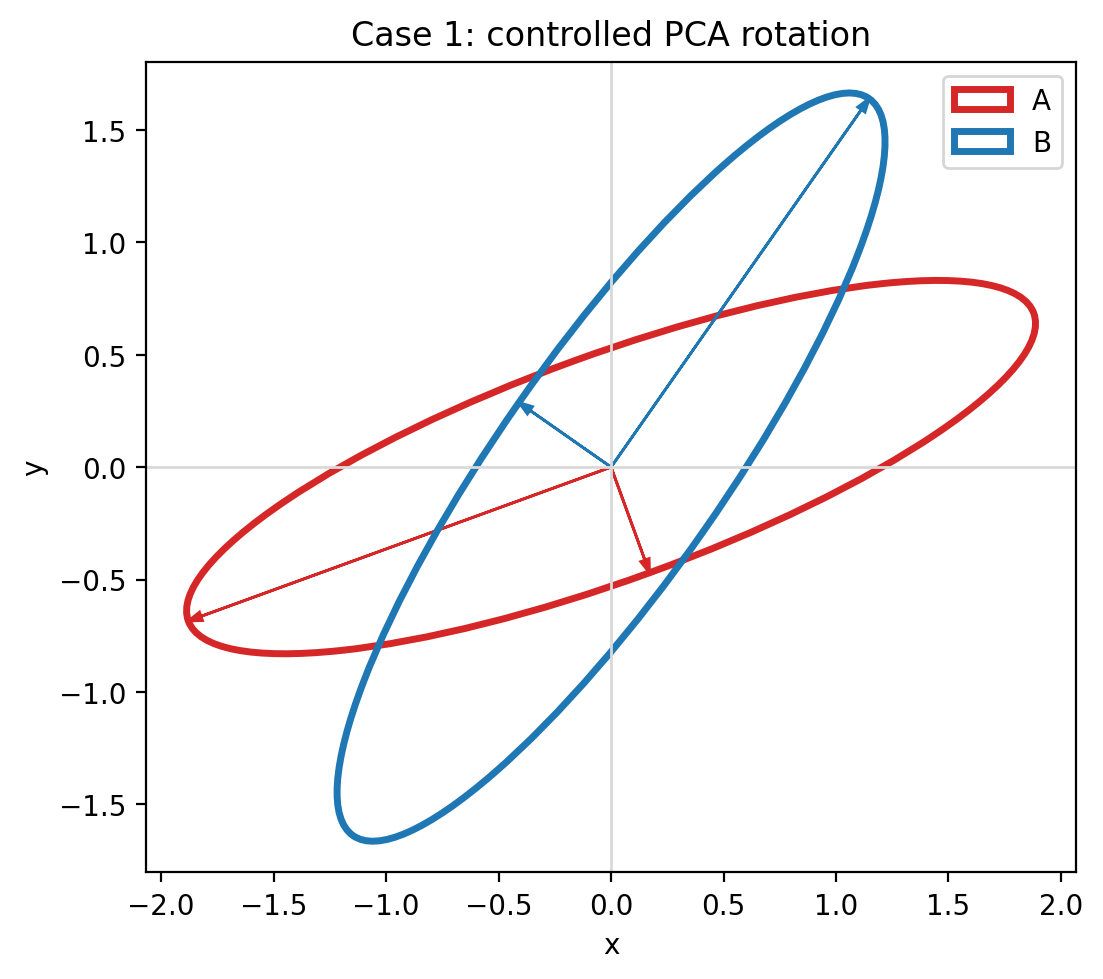

----------------------------------------------------------------------------------------------------
Forecast
Expected PCA rotation difference: 35.0 deg
expected A mode 1 <-> B mode 1: |overlap| = 0.8192
expected A mode 2 <-> B mode 2: |overlap| = 0.8192
expected A mode 1 <-> B mode 2: |overlap| = 0.5736
expected A mode 2 <-> B mode 1: |overlap| = 0.5736
----------------------------------------------------------------------------------------------------

Actual Results
A parameters: x, y
B parameters: x, y

A
Reference posterior

- Mode 1
  - lambda = 4
  - sigma = 2
  - direction = 0.9397 x +0.3420 y

- Mode 2
  - lambda = 0.25
  - sigma = 0.5
  - direction = 0.9397 y -0.3420 x

B
Alternative posterior

- Mode 1
  - lambda = 4
  - sigma = 2
  - direction = 0.8192 y +0.5736 x

- Mode 2
  - lambda = 0.25
  - sigma = 0.5
  - direction = -0.8192 x +0.5736 y

Shifts
- shift metrics unavailable: mean vectors were not provided

Rotations
- basis = original
- A mode 1 <-> B mode 1: |overlap| 

In [3]:
params = ["x", "y"]

sigmas = (2.0, 0.5)
theta_A = 20.0
theta_B = 55.0
expected_rotation = theta_B - theta_A

C_A = covariance_from_axes(sigmas, theta_A)
C_B = covariance_from_axes(sigmas, theta_B)

fig, ax = plt.subplots(figsize=(6, 6))
draw_covariance_ellipse(ax, C_A, "tab:red", "A", nsigma=1.0)
draw_covariance_ellipse(ax, C_B, "tab:blue", "B", nsigma=1.0)
ax.set_title("Case 1: controlled PCA rotation")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.axhline(0.0, color="0.85", lw=1.0)
ax.axvline(0.0, color="0.85", lw=1.0)
ax.set_aspect("equal")
ax.legend()
plt.show()

result_rotation = analyze_covariances(C_A, C_B, params, rotation_basis="original")

forecast_overlap = np.cos(np.deg2rad(expected_rotation))
forecast_mixing = np.sin(np.deg2rad(expected_rotation))

print("--"*50)
print("Forecast")
print(f"Expected PCA rotation difference: {expected_rotation:.1f} deg")
print(f"expected A mode 1 <-> B mode 1: |overlap| = {forecast_overlap:.4f}")
print(f"expected A mode 2 <-> B mode 2: |overlap| = {forecast_overlap:.4f}")
print(f"expected A mode 1 <-> B mode 2: |overlap| = {forecast_mixing:.4f}")
print(f"expected A mode 2 <-> B mode 1: |overlap| = {forecast_mixing:.4f}")
print("--"*50)
print()
print("Actual Results")
print(eigenmode_report(result_rotation, precision=4))
print("--"*50)
np.testing.assert_allclose(result_rotation.eigenvector_overlap, [[abs(forecast_overlap), abs(forecast_mixing)], [abs(forecast_mixing), abs(forecast_overlap)]], atol=1e-12)


## Case 2: Pure Generalized Stretch/Compression Test

Now we test the generalized comparison more directly.

We choose $A = I$, so the whitening with respect to `A` does nothing. Then we define

$$
C_B = U \, \mathrm{diag}(\rho_1, \rho_2) \, U^T,
$$

with a chosen rotation `U` and chosen generalized variance ratios $\rho_1$, $\rho_2$.

In this setup we know *exactly* what the comparison matrix should be, because

$$
C = C_A^{-1/2} C_B C_A^{-1/2} = C_B.
$$

So this is a direct validation of the generalized eigenvalue problem.


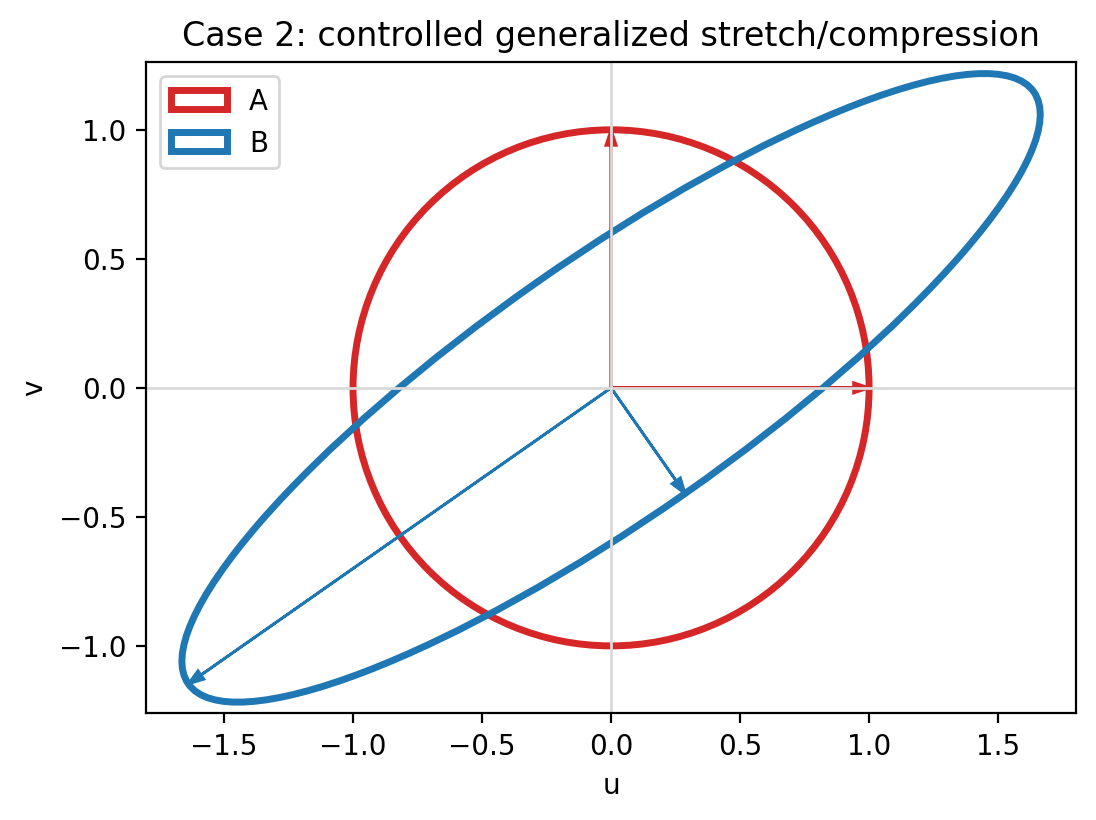

----------------------------------------------------------------------------------------------------
Expected generalized eigenvalues (rho): [4.   0.25]
Recovered generalized eigenvalues: [4.   0.25]

Expected comparison matrix C = B:
[[2.7663 1.7619]
 [1.7619 1.4837]]

Recovered comparison matrix C:
[[2.7663 1.7619]
 [1.7619 1.4837]]
----------------------------------------------------------------------------------------------------


In [4]:
params = ["u", "v"]

rho_expected = np.array([4.0, 0.25])
phi = 35.0
U = rotation_matrix(phi)

C_A = np.eye(2)
C_B = U @ np.diag(rho_expected) @ U.T

result_rho = analyze_covariances(C_A, C_B, params)

fig, ax = plt.subplots(figsize=(6, 6))
draw_covariance_ellipse(ax, C_A, "tab:red", "A", nsigma=1.0)
draw_covariance_ellipse(ax, C_B, "tab:blue", "B", nsigma=1.0)
ax.set_title("Case 2: controlled generalized stretch/compression")
ax.set_xlabel("u")
ax.set_ylabel("v")
ax.axhline(0.0, color="0.85", lw=1.0)
ax.axvline(0.0, color="0.85", lw=1.0)
ax.set_aspect("equal")
ax.legend()
plt.show()

print("--"*50)
print("Expected generalized eigenvalues (rho):", rho_expected)
print("Recovered generalized eigenvalues:", result_rho.degradation_factors)
print()
print("Expected comparison matrix C = B:")
print(pretty_matrix(C_B))
print()
print("Recovered comparison matrix C:")
print(pretty_matrix(result_rho.whitened_comparison_matrix))
print("--"*50)
np.testing.assert_allclose(result_rho.degradation_factors, rho_expected, rtol=1e-12)


## Case 3: Mixed Test with Controlled PCA Geometry and Controlled Relative Change

Finally we combine the two ideas.

We first choose a non-trivial reference posterior `A`, then we build `B` from

$
C_B = C_A^{1/2} \, U \, \mathrm{diag}(\rho_1, \rho_2) \, U^T \, C_A^{1/2}.
$

This guarantees that the comparison matrix is exactly

$
C = U \, \mathrm{diag}(\rho_1, \rho_2) \, U^T.
$

So here we can test simultaneously:

- non-trivial PCA geometry for `A`,
- non-trivial PCA geometry for `B`,
- controlled generalized `\rho_i`,
- controlled comparison-basis rotation.


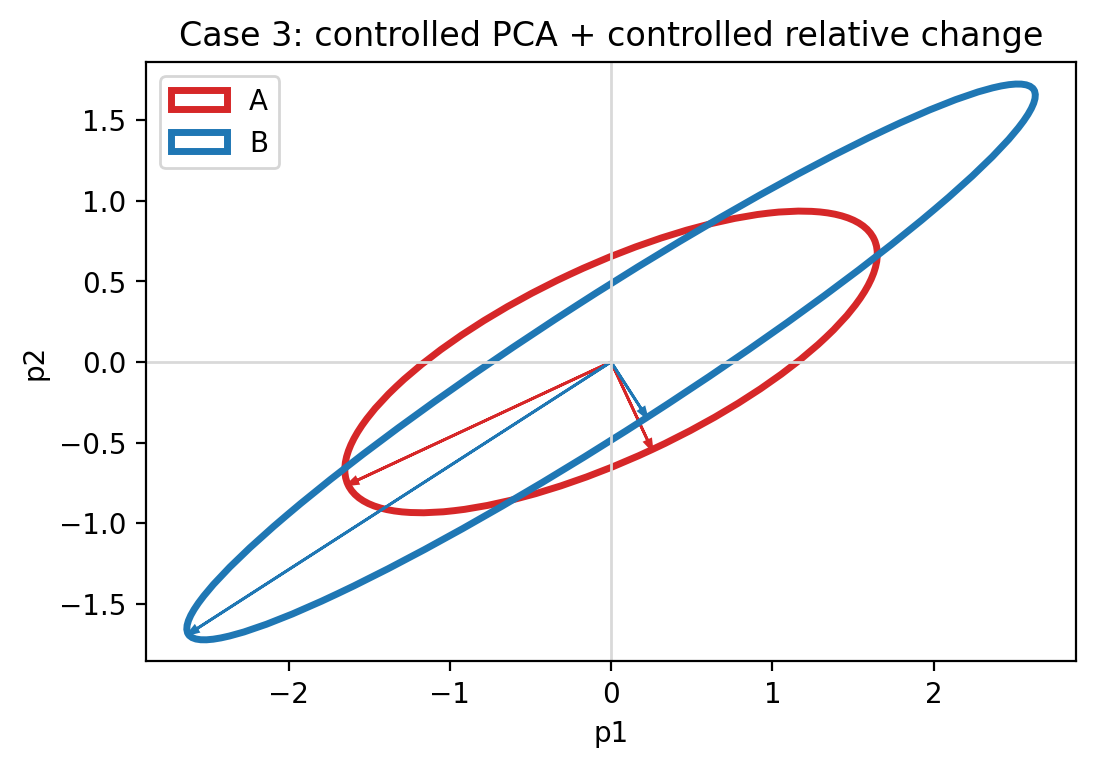

----------------------------------------------------------------------------------------------------
Expected generalized eigenvalues (rho): [3.5 0.4]
Recovered generalized eigenvalues: [3.5 0.4]

Expected PCA eigenvalues of A: [3.24 0.36]
Recovered PCA eigenvalues of A: [3.24 0.36]

Expected PCA eigenvalues of B: [9.72142858 0.16797531]
Recovered PCA eigenvalues of B: [9.72142858 0.16797531]

Expected PCA overlap matrix:
[[0.9908 0.1355]
 [0.1355 0.9908]]

Recovered PCA overlap matrix:
[[0.9908 0.1355]
 [0.1355 0.9908]]

A parameters: p1, p2
B parameters: p1, p2

A
Reference posterior

- Mode 1
  - lambda = 3.24
  - sigma = 1.8
  - direction = 0.9063 p1 +0.4226 p2

- Mode 2
  - lambda = 0.36
  - sigma = 0.6
  - direction = 0.9063 p2 -0.4226 p1

B
Alternative posterior

- Mode 1
  - lambda = 9.721
  - sigma = 3.118
  - direction = 0.8407 p1 +0.5415 p2

- Mode 2
  - lambda = 0.168
  - sigma = 0.4098
  - direction = 0.8407 p2 -0.5415 p1

Shifts
- shift metrics unavailable: mean vectors w

In [5]:
def symmetric_sqrt(C):
    evals, evecs = np.linalg.eigh(C)
    return evecs @ np.diag(np.sqrt(evals)) @ evecs.T


def ordered_eigensystem(C):
    evals, evecs = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]
    return evals[order], evecs[:, order]


params = ["p1", "p2"]

C_A = covariance_from_axes(sigmas=(1.8, 0.6), theta_deg=25.0)
U = rotation_matrix(50.0)
rho_expected = np.array([3.5, 0.4])
C_B = symmetric_sqrt(C_A) @ U @ np.diag(rho_expected) @ U.T @ symmetric_sqrt(C_A)

evals_A_expected, evecs_A_expected = ordered_eigensystem(C_A)
evals_B_expected, evecs_B_expected = ordered_eigensystem(C_B)
overlap_expected = np.abs(evecs_A_expected.T @ evecs_B_expected)

fig, ax = plt.subplots(figsize=(6, 6))
draw_covariance_ellipse(ax, C_A, "tab:red", "A", nsigma=1.0)
draw_covariance_ellipse(ax, C_B, "tab:blue", "B", nsigma=1.0)
ax.set_title("Case 3: controlled PCA + controlled relative change")
ax.set_xlabel("p1")
ax.set_ylabel("p2")
ax.axhline(0.0, color="0.85", lw=1.0)
ax.axvline(0.0, color="0.85", lw=1.0)
ax.set_aspect("equal")
ax.legend()
plt.show()

result_mixed = analyze_covariances(C_A, C_B, params, rotation_basis="original")

print("--"*50)
print("Expected generalized eigenvalues (rho):", rho_expected)
print("Recovered generalized eigenvalues:", result_mixed.degradation_factors)
print()
print("Expected PCA eigenvalues of A:", evals_A_expected)
print("Recovered PCA eigenvalues of A:", result_mixed.reference_eigenvalues)
print()
print("Expected PCA eigenvalues of B:", evals_B_expected)
print("Recovered PCA eigenvalues of B:", result_mixed.alternative_eigenvalues)
print()
print("Expected PCA overlap matrix:")
print(pretty_matrix(overlap_expected))
print()
print("Recovered PCA overlap matrix:")
print(pretty_matrix(result_mixed.eigenvector_overlap))
print()
print(eigenmode_report(result_mixed, precision=4))
print("--"*50)

np.testing.assert_allclose(result_mixed.degradation_factors, rho_expected, rtol=1e-12)
np.testing.assert_allclose(result_mixed.eigenvector_overlap, overlap_expected, atol=1e-12)


## Case 4: Projection Effect in 3D

This case is designed to mimic the qualitative situation that often appears in real analyses:

- a 2D marginal contour can look strongly rotated or qualitatively reshaped,
- while the full `n`-dimensional eigenvector bases remain essentially unchanged.

This cannot happen in a genuinely 2D Gaussian problem, because in 2D the contour orientation is directly controlled by the covariance eigenvectors. To reproduce the effect, we need at least 3 dimensions.

The idea here is even cleaner than a small-rotation toy model:

- build `A` and `B` with exactly the same 3D eigenbasis,
- change only the eigenvalue hierarchy,
- then show that the `(x, z)` marginal can still change dramatically.

So this case isolates a pure projection effect: the apparent 2D rotation is not caused by a true rotation of the full PCA basis.



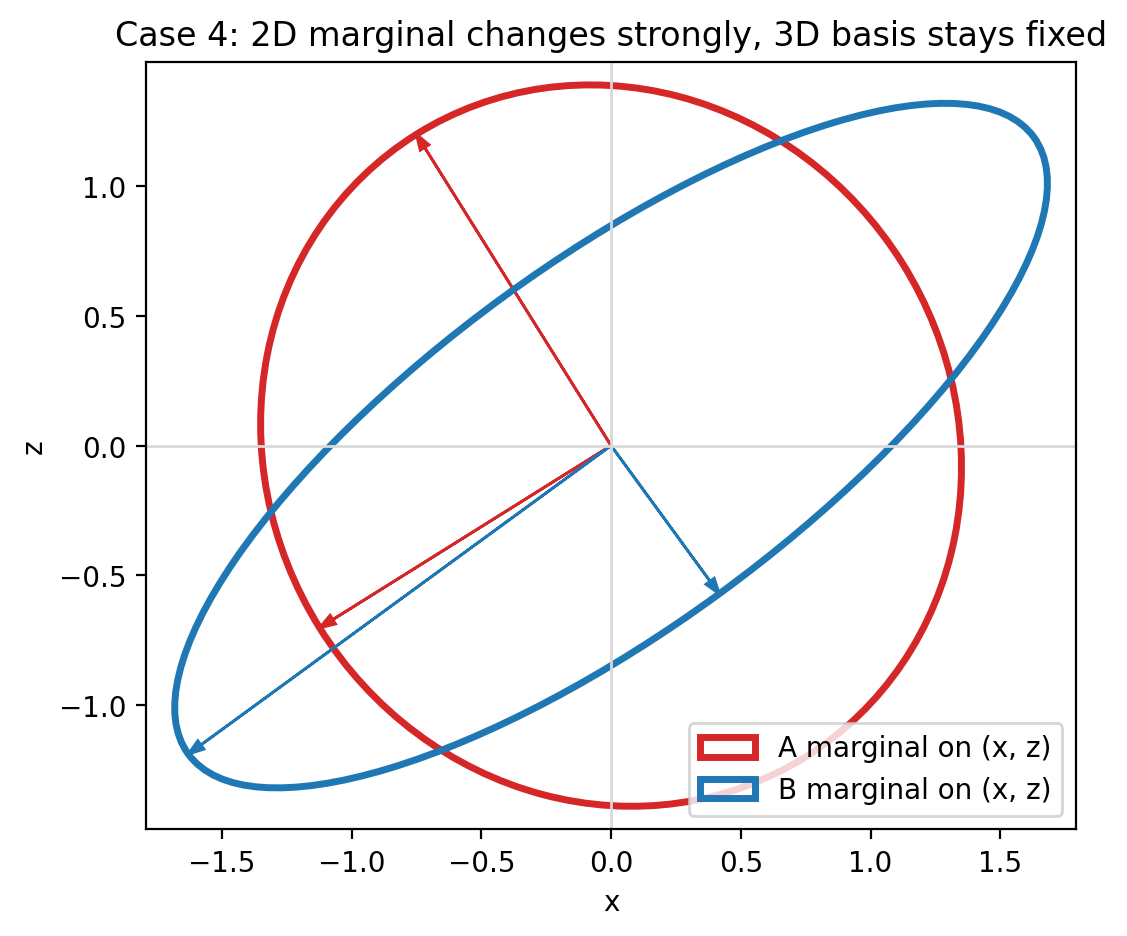

----------------------------------------------------------------------------------------------------
Expected behavior
The full 3D eigenbasis of A and B is the same by construction.
So the expected 3D overlap matrix is the identity.
At the same time, the 2D marginal on (x, z) is expected to change a lot.

Expected marginal corr(x, z) in A: -0.0592
Expected marginal corr(x, z) in B: 0.7659

Expected PCA eigenvalues of A: [5.  2.  0.1]
Recovered PCA eigenvalues of A: [5.  2.  0.1]

Expected PCA eigenvalues of B: [12.    0.5   0.02]
Recovered PCA eigenvalues of B: [12.    0.5   0.02]

Expected 3D overlap matrix:
[[1.0000e+00 1.3092e-16 9.7119e-18]
 [2.6750e-17 1.0000e+00 2.3868e-15]
 [3.6082e-16 2.3870e-15 1.0000e+00]]

Recovered 3D overlap matrix:
[[1.0000e+00 1.2117e-16 1.5335e-16]
 [2.6114e-16 1.0000e+00 1.0320e-16]
 [1.6645e-17 1.6235e-16 1.0000e+00]]

Recovered top 3D eigenvector alignments:
EigenvectorAlignment(reference_mode_index=1, alternative_mode_index=1, overlap=1.0)
Eigenvect

In [6]:
params = ["x", "y", "z"]


def rotation_matrix_x(theta_deg: float) -> np.ndarray:
    theta = np.deg2rad(theta_deg)
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[1.0, 0.0, 0.0], [0.0, c, -s], [0.0, s, c]])


def rotation_matrix_y(theta_deg: float) -> np.ndarray:
    theta = np.deg2rad(theta_deg)
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, 0.0, s], [0.0, 1.0, 0.0], [-s, 0.0, c]])


def rotation_matrix_z(theta_deg: float) -> np.ndarray:
    theta = np.deg2rad(theta_deg)
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]])


def ordered_eigensystem(C):
    evals, evecs = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]
    return evals[order], evecs[:, order]


Q = rotation_matrix_z(-60.0) @ rotation_matrix_y(-20.0) @ rotation_matrix_x(-60.0)

# Same 3D eigenbasis for A and B, but different eigenvalue hierarchies.
# This means that the full n-dimensional eigenvectors do not rotate,
# while a 2D marginal can still change dramatically.
D_A = np.diag([5.0, 2.0, 0.1])
D_B = np.diag([12.0, 0.5, 0.02])

C_A = Q @ D_A @ Q.T
C_B = Q @ D_B @ Q.T

result_projection = analyze_covariances(C_A, C_B, params, rotation_basis="original")

# Expected quantities from construction
expected_evals_A, expected_evecs_A = ordered_eigensystem(C_A)
expected_evals_B, expected_evecs_B = ordered_eigensystem(C_B)
expected_overlap = np.abs(expected_evecs_A.T @ expected_evecs_B)

# Show the 2D marginal on (x, z), where the projection effect is visible.
C_A_xz = C_A[np.ix_([0, 2], [0, 2])]
C_B_xz = C_B[np.ix_([0, 2], [0, 2])]

corr_A_xz = C_A_xz[0, 1] / np.sqrt(C_A_xz[0, 0] * C_A_xz[1, 1])
corr_B_xz = C_B_xz[0, 1] / np.sqrt(C_B_xz[0, 0] * C_B_xz[1, 1])

fig, ax = plt.subplots(figsize=(6, 6))
draw_covariance_ellipse(ax, C_A_xz, "tab:red", "A marginal on (x, z)", nsigma=1.0)
draw_covariance_ellipse(ax, C_B_xz, "tab:blue", "B marginal on (x, z)", nsigma=1.0)
ax.set_title("Case 4: 2D marginal changes strongly, 3D basis stays fixed")
ax.set_xlabel("x")
ax.set_ylabel("z")
ax.axhline(0.0, color="0.85", lw=1.0)
ax.axvline(0.0, color="0.85", lw=1.0)
ax.set_aspect("equal")
ax.legend()
plt.show()

print("-" * 100)
print("Expected behavior")
print("The full 3D eigenbasis of A and B is the same by construction.")
print("So the expected 3D overlap matrix is the identity.")
print("At the same time, the 2D marginal on (x, z) is expected to change a lot.")
print()

print("Expected marginal corr(x, z) in A:", f"{corr_A_xz:.4f}")
print("Expected marginal corr(x, z) in B:", f"{corr_B_xz:.4f}")
print()

print("Expected PCA eigenvalues of A:", expected_evals_A)
print("Recovered PCA eigenvalues of A:", result_projection.reference_eigenvalues)
print()

print("Expected PCA eigenvalues of B:", expected_evals_B)
print("Recovered PCA eigenvalues of B:", result_projection.alternative_eigenvalues)
print()

print("Expected 3D overlap matrix:")
print(pretty_matrix(expected_overlap))
print()

print("Recovered 3D overlap matrix:")
print(pretty_matrix(result_projection.eigenvector_overlap))
print()

print("Recovered top 3D eigenvector alignments:")
for alignment in top_eigenvector_alignments(result_projection, top_n=6):
    print(alignment)
print()

print(eigenmode_report(result_projection, precision=4))
print("-" * 100)

np.testing.assert_allclose(result_projection.eigenvector_overlap, np.eye(3), atol=1e-12)
np.testing.assert_allclose(result_projection.degradation_factors, [2.4, .25, .2], rtol=1e-12)


## Case 5: Unit-invariant rotation and numerical identities

The two matrices are expressed first in original units, then with one parameter
rescaled by 100. Standardized overlaps and all generalized scalar indicators must
remain unchanged. The raw overlaps need not agree. Ellipses below use the common
reference-sigma coordinates; their geometry is independent of the original units.


Expected standardized overlap: invariant under unit changes
Original units:
 [[0.50566621 0.86272921]
 [0.86272921 0.50566621]]
Changed units:
 [[0.50566621 0.86272921]
 [0.86272921 0.50566621]]
Numerical residuals: {'generalized_residual': 2.5660398141097347e-16, 'reference_orthogonality_error': 1.1210202063909607e-16, 'alternative_diagonalization_error': 4.442869166934145e-16, 'reference_correlation_condition': 2.636363636363637, 'alternative_correlation_condition': 1.8002333284748548}


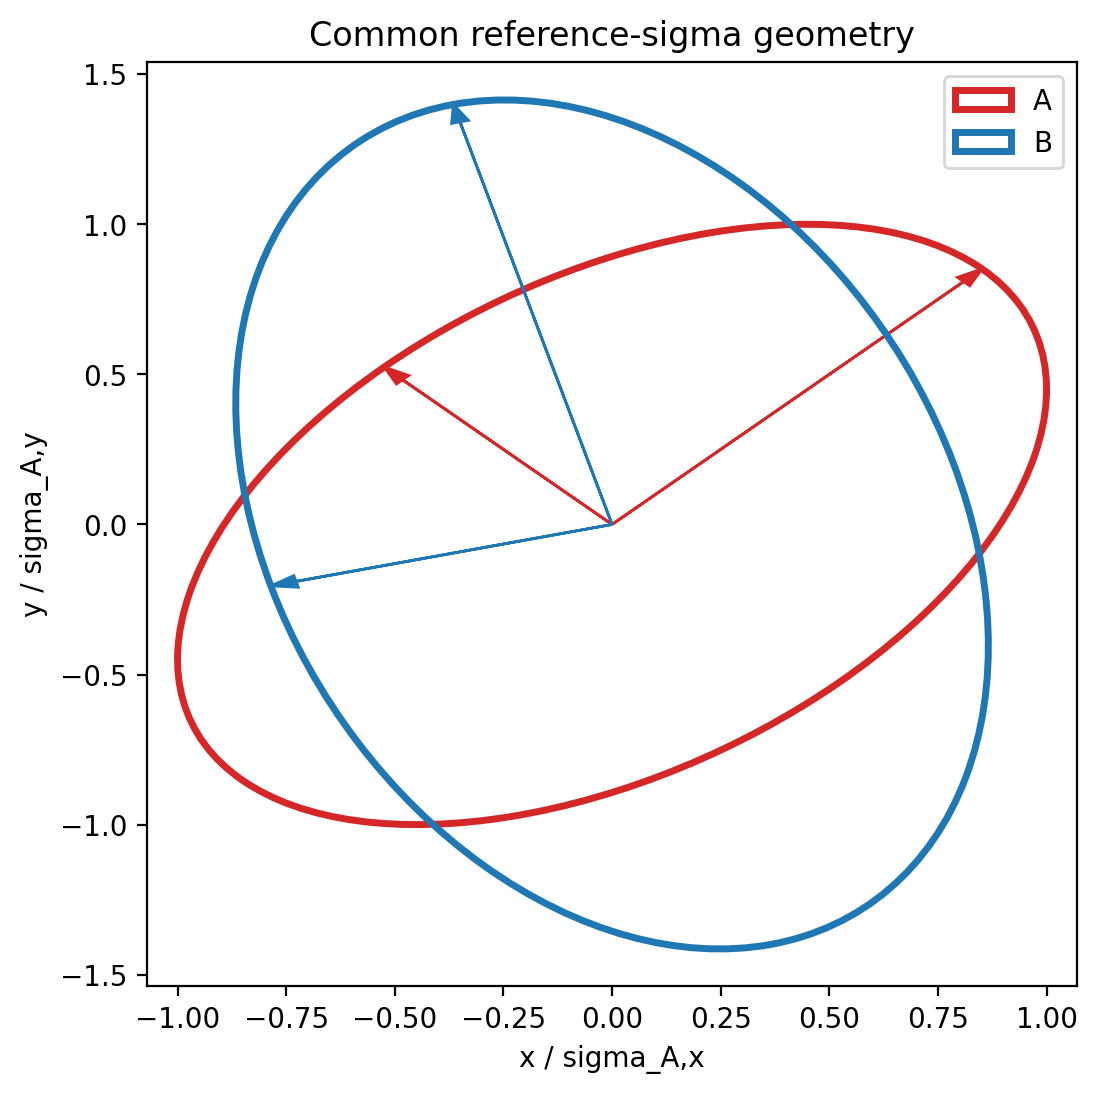

In [7]:
A = np.array([[4., .9], [.9, 1.]])
B = np.array([[3., -.7], [-.7, 2.]])
scale_change = np.diag([100., 1.])
r = analyze_covariances(A, B, ["x", "y"])
t = analyze_covariances(scale_change @ A @ scale_change, scale_change @ B @ scale_change, ["x", "y"])
np.testing.assert_allclose(r.eigenvector_overlap, t.eigenvector_overlap, atol=1e-12)
np.testing.assert_allclose(r.degradation_factors, t.degradation_factors, rtol=1e-12)
V = r.mode_vectors
np.testing.assert_allclose(V.T @ A @ V, np.eye(2), atol=1e-12)
np.testing.assert_allclose(V.T @ B @ V, np.diag(r.degradation_factors), atol=1e-12)
print("Expected standardized overlap: invariant under unit changes")
print("Original units:\n", r.eigenvector_overlap)
print("Changed units:\n", t.eigenvector_overlap)
print("Numerical residuals:", r.numerical_diagnostics)
Dinv = np.diag(1 / np.sqrt(np.diag(A)))
fig, ax = plt.subplots(figsize=(6, 6))
draw_covariance_ellipse(ax, Dinv @ A @ Dinv, "tab:red", "A")
draw_covariance_ellipse(ax, Dinv @ B @ Dinv, "tab:blue", "B")
ax.set(xlabel="x / sigma_A,x", ylabel="y / sigma_A,y", title="Common reference-sigma geometry")
ax.autoscale_view()
ax.legend()
plt.show()


## Case 6: Weighted projections, shifts and normalization

Create weighted samples with a known affine change. Derive covariances from those
same samples so the projected covariance identities can be checked directly.

The empirical weighted covariance of A is made exactly diagonal before applying
the known stretch. This makes the predicted rho exact, not an approximation that
ignores finite-sample cross-correlations.


In [8]:
from getdist import MCSamples
from postmodes.api import compare_samples
from postmodes import get_mode_samples
from postmodes.stats import weighted_covariance, weighted_mean

rng = np.random.default_rng(14)
x = rng.normal(size=(1500, 2)) * [2., .5]
weights = rng.integers(1, 10, size=len(x)).astype(float)
x -= weighted_mean(x, weights)
L = np.linalg.cholesky(weighted_covariance(x, weights))
x = np.linalg.solve(L, x.T).T * [2., .5]
sample_A = MCSamples(samples=x, weights=weights, names=["x", "y"])
sample_B = MCSamples(samples=x * [1.5, .7] + [3., -1.], weights=weights, names=["x", "y"])
r_weighted = compare_samples(sample_A, sample_B)
ma, mb = get_mode_samples(sample_A, sample_B, r_weighted)
np.testing.assert_allclose(weighted_covariance(ma, weights), np.eye(2), atol=1e-12)
np.testing.assert_allclose(weighted_covariance(mb, weights), np.diag(r_weighted.degradation_factors), atol=1e-12)
np.testing.assert_allclose(weighted_mean(mb, weights), (r_weighted.alternative_mean-r_weighted.reference_mean) @ r_weighted.mode_vectors, atol=1e-12)
print("Expected rho:", [2.25, .49])
print("Recovered rho:", r_weighted.degradation_factors)
np.testing.assert_allclose(r_weighted.degradation_factors, [2.25, .49], rtol=1e-12, atol=1e-12)
delta_expected = np.array([3., -1.])
CA_expected = np.diag([4., .25])
CB_expected = np.diag([9., .1225])
shift_expected = [np.sqrt(delta_expected @ np.linalg.solve(C, delta_expected))
                  for C in [CA_expected, CB_expected, CA_expected + CB_expected]]
print("Expected shifts:", shift_expected)
print("Recovered shifts:", r_weighted.shifts)
np.testing.assert_allclose(list(r_weighted.shifts.values()), shift_expected, rtol=1e-12)
print("Both weighted projection identities passed.")


Removed no burn in
Removed no burn in
Expected rho: [2.25, 0.49]
Recovered rho: [2.25 0.49]
Expected shifts: [np.float64(2.5), np.float64(3.0270885857738703), np.float64(1.8376265808637384)]
Recovered shifts: {'B_in_A': 2.499999999999998, 'A_in_B': 3.0270885857738676, 'SCCD': 1.8376265808637373}
Both weighted projection identities passed.


## Case 7: Optional Monte Carlo stability

This synthetic example uses independent draws and a block length of 10 only to
exercise the interface. For real MCMC, choose block lengths from autocorrelation
checks and test several lengths. Supply separate chronological post-burn-in chains;
retain weights. Percentiles describe Monte Carlo stability, not tension significance.


In [9]:
from postmodes import bootstrap_stability

# Independent sampling runs for A and B, unlike the paired transform in Case 6.
chains_A = [rng.normal(size=(1000, 2)) * [2., .5] for _ in range(2)]
chains_B = [rng.normal(size=(1000, 2)) * [3., .35] + [3., -1.] for _ in range(2)]
stability = bootstrap_stability(chains_A, chains_B, parameter_names_a=["x", "y"],
                                block_length=10, n_resamples=30, seed=7)
print("metric | estimate | bootstrap 16%, 50%, 84%")
for name, value, interval in zip(stability["names"], stability["estimate"], stability["quantiles"].T):
    print(f"{name}: {value:.4g} {interval}")
print("Failed replicates:", stability["failed_resamples"])
assert stability["failed_resamples"] == 0


metric | estimate | bootstrap 16%, 50%, 84%
B_in_A: 2.521 [2.47406024 2.52187903 2.57790161]
A_in_B: 3.064 [3.00614369 3.08877559 3.14930196]
SCCD: 1.857 [1.83198225 1.86286486 1.89666057]
alpha: 1.062 [1.01696076 1.0551477  1.08354   ]
A_aniso: 0.7691 [0.73866812 0.77084921 0.79198095]
rho_1: 2.291 [2.2082386  2.27638461 2.33827506]
rho_2: 0.4922 [0.47252165 0.4864106  0.51230425]
Failed replicates: 0
